# LightGBM Model

This notebook trains a LightGBM model for cancellation prediction.


In [ ]:
import sys
import os
import pickle
import warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import lightgbm as lgb
from sklearn.metrics import (
    fbeta_score, precision_score, recall_score,
    average_precision_score, roc_auc_score, f1_score
)

sys.path.append(os.path.abspath(".."))
from src.evaluation import evaluate_model, find_optimal_threshold, METRIC_TARGETS

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

In [2]:
data_dir = "../data/silver"

X_train = pd.read_parquet(os.path.join(data_dir, "X_train.parquet"))
X_val = pd.read_parquet(os.path.join(data_dir, "X_val.parquet"))
X_test = pd.read_parquet(os.path.join(data_dir, "X_test.parquet"))

y_train = pd.read_parquet(os.path.join(data_dir, "y_train.parquet"))['is_cancelled']
y_val = pd.read_parquet(os.path.join(data_dir, "y_val.parquet"))['is_cancelled']
y_test = pd.read_parquet(os.path.join(data_dir, "y_test.parquet"))['is_cancelled']

print(f"X_train shape: {X_train.shape}")

X_train shape: (112705, 18)


In [3]:
# evaluate_model, find_optimal_threshold imported from src.evaluation

## Train LightGBM

In [4]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight: {scale_pos_weight:.2f}")

model = lgb.LGBMClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    eval_metric='average_precision',
    callbacks=[lgb.early_stopping(20, verbose=False)]
)
print(f"Model trained. Best iteration: {model.best_iteration_}")

scale_pos_weight: 2.12
Model trained. Best iteration: 16


In [5]:
y_val_prob = model.predict_proba(X_val)[:, 1]
y_test_prob = model.predict_proba(X_test)[:, 1]

In [6]:
optimal_threshold, best_f2 = find_optimal_threshold(y_val, y_val_prob)
print(f"Optimal threshold: {optimal_threshold:.2f}")
print(f"Best F2-Score: {best_f2:.4f}")

Optimal threshold: 0.21
Best F2-Score: 0.7355


In [7]:
y_val_pred = (y_val_prob >= optimal_threshold).astype(int)
y_test_pred = (y_test_prob >= optimal_threshold).astype(int)

val_metrics = evaluate_model(y_val, y_val_pred, y_val_prob, "Validation")
test_metrics = evaluate_model(y_test, y_test_pred, y_test_prob, "Test")


EVALUATION - Validation
F2-Score:  0.7355 ✅
Recall:    0.9599 ✅
Precision: 0.3800 ❌
PR-AUC:    0.6216
ROC-AUC:   0.7412

EVALUATION - Test
F2-Score:  0.7343 ✅
Recall:    0.9562 ✅
Precision: 0.3808 ❌
PR-AUC:    0.6185
ROC-AUC:   0.7353



Feature Importance:
                 feature  importance
0       avg_vtat_imputed         197
5   vehicle_type_encoded          17
15               dow_cos          17
13              hour_cos          15
8                  month          14
6                   hour          14
12              hour_sin          14
4           drop_encoded          13
17             month_cos          11
3         pickup_encoded           9
7              dayofweek           6
14               dow_sin           4
16             month_sin           2
10          is_peak_hour           1
1            vtat_bucket           0
2           is_high_vtat           0
9             is_weekend           0
11         is_late_night           0


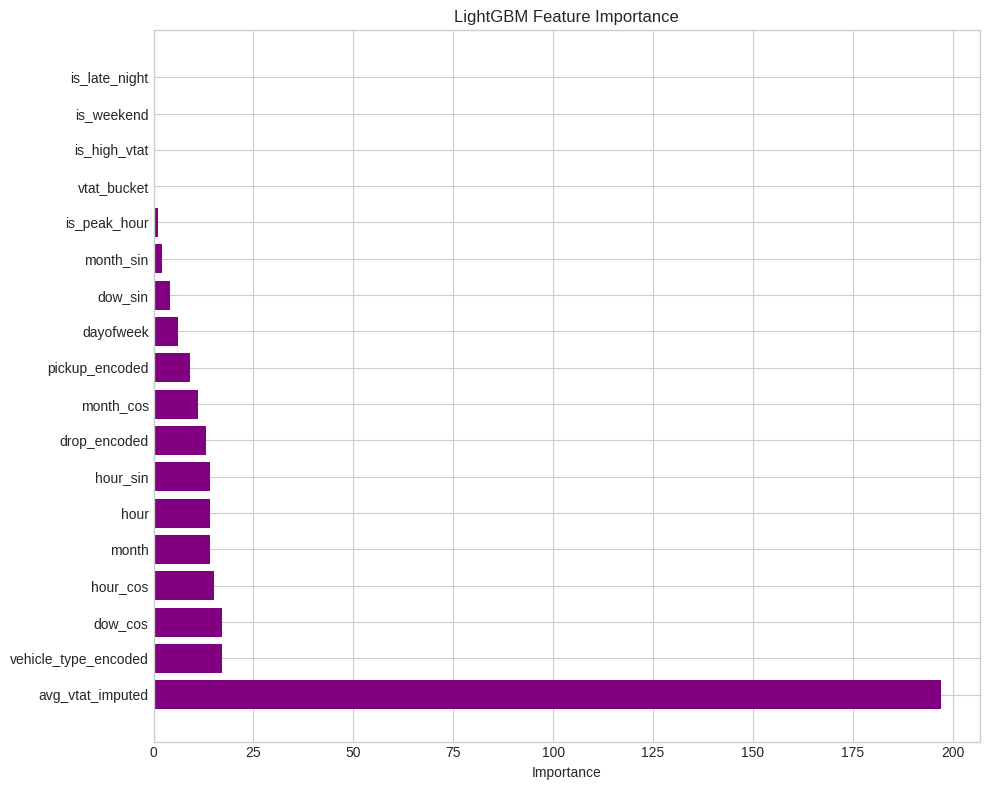

In [8]:
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nFeature Importance:")
print(feature_importance)

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(feature_importance['feature'], feature_importance['importance'], color='purple')
ax.set_xlabel('Importance')
ax.set_title('LightGBM Feature Importance')
plt.tight_layout()
plt.show()

In [9]:
models_dir = "../models"
os.makedirs(models_dir, exist_ok=True)

model_artifacts = {
    'model': model,
    'optimal_threshold': optimal_threshold,
    'feature_names': list(X_train.columns),
    'metrics': {'validation': val_metrics, 'test': test_metrics}
}

with open(os.path.join(models_dir, "lightgbm.pkl"), 'wb') as f:
    pickle.dump(model_artifacts, f)

print(f"Model saved to {models_dir}/lightgbm.pkl")

Model saved to ../models/lightgbm.pkl


In [11]:
print("LIGHTGBM - FINAL SUMMARY")
print("-"*60)
print(f"Optimal Threshold: {optimal_threshold:.2f}")
print(f"\nTest Set Performance:")
print(f"  F2-Score:  {test_metrics['f2']:.4f}")
print(f"  Recall:    {test_metrics['recall']:.4f}")
print(f"  Precision: {test_metrics['precision']:.4f}")

LIGHTGBM - FINAL SUMMARY
------------------------------------------------------------
Optimal Threshold: 0.21

Test Set Performance:
  F2-Score:  0.7343
  Recall:    0.9562
  Precision: 0.3808
